# VAE

In [1]:
from src.dataset import load_mnist_dataset, load_shapes_npz
from src.autoencoder import AutoEncoder
from src.vae import VariationalAutoEncoder
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent
from src.viz import (
    finish_figure,
    show_image_grid,
    show_labeled_image_rows,
    plot_latent_scatter,
    print_compression_report,
    sample_gaussian_latent,
    generate_from_latent_using_gaussian,
    interpolate_latent,
    subsample_dataset,
)

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

print("device:", get_device())

EPOCHS = 40
EPOCHS_SWEEP = 40
BATCH_SIZE = 128

device: cuda


In [2]:
def note(**kw):
    """Note grise sous une figure: on ecrit ce qu'on veut y voir, rien de plus."""
    return "fixe: " + " | ".join(f"{k}={v}" for k, v in kw.items())


def run_vae(X_train, X_eval, input_dim, latent_dim, activation, epochs,
            loss_function=nn.BCELoss, beta=1.0, output_activation=nn.Sigmoid,
            n_layers=3, learning_rate=1e-3, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    model = VariationalAutoEncoder(
        input_dim=input_dim, output_dim=input_dim, latent_dim=latent_dim,
        encoder_layer_num=n_layers, decoder_layer_num=n_layers,
        encoder_activation_function=activation, loss_function=loss_function,
        beta=beta, output_activation_function=output_activation,
    )
    model.fit(X_train, epochs=epochs, batch_size=BATCH_SIZE, learning_rate=learning_rate)
    latent = model.encode(X_eval)
    reconstruction = model.decode(latent)
    report = compression_report(model.get_codebook(), latent, X_eval, reconstruction)
    return {"model": model, "latent": latent, "reconstruction": reconstruction, "report": report}


def posterior_stats(model, X_eval):
    """KL par dimension et nb de dimensions actives. Une dimension dont le KL est ~0 rend
    exactement le prior: elle ne transporte rien et le decodeur l'ignore (collapse)."""
    mu, logvar = model.encode_distribution(X_eval)
    kl = model.kl_per_dim(torch.from_numpy(mu), torch.from_numpy(logvar)).numpy()
    return {"mu": mu, "sigma": np.exp(0.5 * logvar), "kl_per_dim": kl,
            "kl_total": float(kl.sum()), "dims_actives": int((kl > 0.01).sum())}


def prior_gap(codes):
    """Distance du nuage de codes au prior N(0, I): decentrage et deformation. 0 = parfait."""
    centre = float(np.linalg.norm(codes.mean(axis=0)))
    deformation = float(np.linalg.norm(np.cov(codes, rowvar=False) - np.eye(codes.shape[1])))
    return centre, deformation

## Partie A - MNIST DIGITS

In [3]:
mnist_train_images, mnist_train_labels = extract_full_dataset(load_mnist_dataset(train=True, shuffle=False))
mnist_eval_images, mnist_eval_labels = extract_full_dataset(load_mnist_dataset(train=False, shuffle=False))

MNIST_SHAPE = (1, 28, 28)
X_mnist_train, y_mnist_train = subsample_dataset(
    mnist_train_images.reshape(len(mnist_train_images), -1).numpy(), mnist_train_labels.numpy(), 15000
    )
X_mnist_eval, y_mnist_eval = subsample_dataset(
    mnist_eval_images.reshape(len(mnist_eval_images), -1).numpy(), mnist_eval_labels.numpy(), 3000
    )
X_tr, y_tr = subsample_dataset(X_mnist_train, y_mnist_train, 6000, seed=1)
print("train:", X_mnist_train.shape, "| eval:", X_mnist_eval.shape, "| sweeps:", X_tr.shape)

train: (15000, 784) | eval: (3000, 784) | sweeps: (6000, 784)


### Train - VAE et AutoEncoder

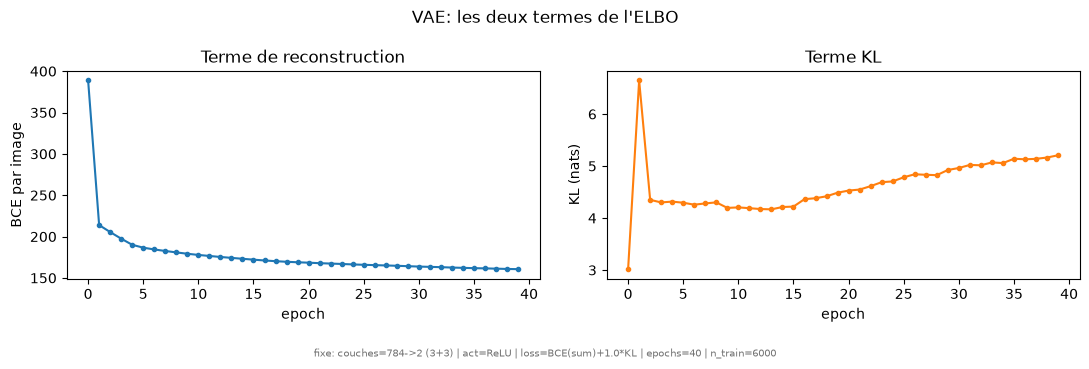

In [ ]:
GRAINE = 0

vae_run = run_vae(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS, beta=1.0, seed=GRAINE)
vae_model = vae_run["model"]

torch.manual_seed(GRAINE)
ae_model = AutoEncoder(input_dim=784, output_dim=784, latent_dim=2,
                       encoder_layer_num=3, decoder_layer_num=3,
                       encoder_activation_function=nn.ReLU, loss_function=nn.MSELoss)
ae_model.fit(X_tr, epochs=EPOCHS, batch_size=BATCH_SIZE)
ae_latent = ae_model.encode(X_mnist_eval)
ae_reconstruction = ae_model.decode(ae_latent)

VAE_NOTE = note(couches="784->2 (3+3)", act="ReLU", loss="BCE(sum)+1.0*KL",
                epochs=EPOCHS, n_train=len(X_tr))

# Les deux termes separement: ils n'ont pas la meme unite, c'est leur equilibre qui compte.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(vae_model.recon_history, marker=".")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE par image")
axes[0].set_title("Terme de reconstruction")
axes[1].plot(vae_model.kl_history, marker=".", color="tab:orange")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("KL (nats)")
axes[1].set_title("Terme KL")
finish_figure(fig, "VAE: les deux termes de l'ELBO", VAE_NOTE)

### Compression et decompression

=== AutoEncoder (MSE) ===
           latent_nature: continuous
          codebook_bytes: 345276
            latent_bytes: 24000
  total_compressed_bytes: 369276
          original_bytes: 9408000
       compression_ratio: 25.4769
      reconstruction_mse: 0.0490

=== VAE (BCE + KL) ===
           latent_nature: continuous
          codebook_bytes: 345276
            latent_bytes: 24000
  total_compressed_bytes: 369276
          original_bytes: 9408000
       compression_ratio: 25.4769
      reconstruction_mse: 0.0482

Message par image: 8 octets dans les deux cas.


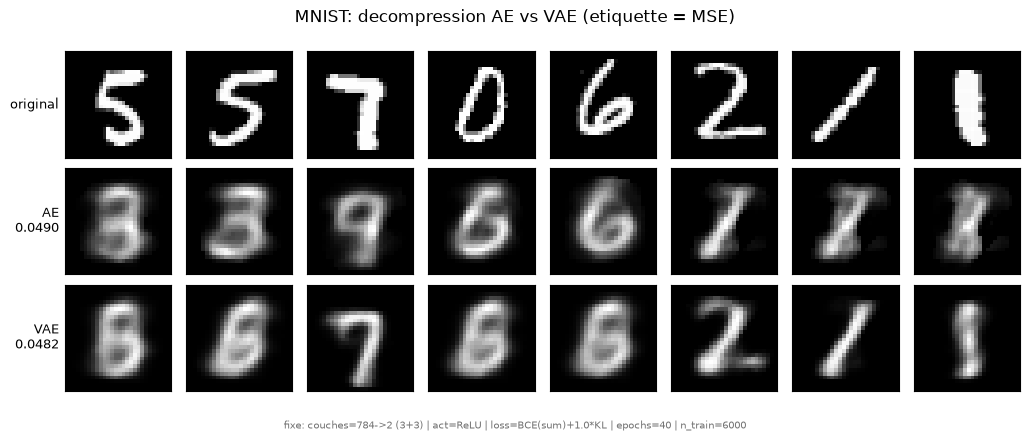

In [5]:
vae_latent, vae_reconstruction = vae_run["latent"], vae_run["reconstruction"]

print("=== AutoEncoder (MSE) ===")
ae_report = compression_report(ae_model.get_codebook(), ae_latent, X_mnist_eval, ae_reconstruction)
print_compression_report(ae_report)
print("\n=== VAE (BCE + KL) ===")
print_compression_report(vae_run["report"])
print(f"\nMessage par image: {vae_latent.n_bytes / len(X_mnist_eval):.0f} octets dans les deux cas.")

show_labeled_image_rows(
    [X_mnist_eval, ae_reconstruction, vae_reconstruction],
    MNIST_SHAPE,
    ["original",
     f"AE\n{ae_report['reconstruction_mse']:.4f}",
     f"VAE\n{vae_run['report']['reconstruction_mse']:.4f}"],
    n=8, title="MNIST: decompression AE vs VAE (etiquette = MSE)", config=VAE_NOTE,
)

### Preuve 1/2 : la geometrie de l'espace latent

Si le KL a marche, le nuage des `mu` doit ressembler a `N(0, I)`: centre a l'origine, covariance
identite. Les cercles a 1 et 2 ecarts-types du prior sont traces par-dessus. Sur l'AE ils n'ont
aucun rapport avec les donnees; sur le VAE ils doivent tomber juste.

             |  ||E[mu]|| |  ||Cov-I||_F
 AutoEncoder |      9.418 |       41.930
         VAE |      0.133 |        1.090

KL du VAE: 5.196 nats | par dimension: [2.574 2.622]
sigma par dimension: [0.123 0.122] (le prior impose 1.0; plus petit = la dimension transporte de l'information)


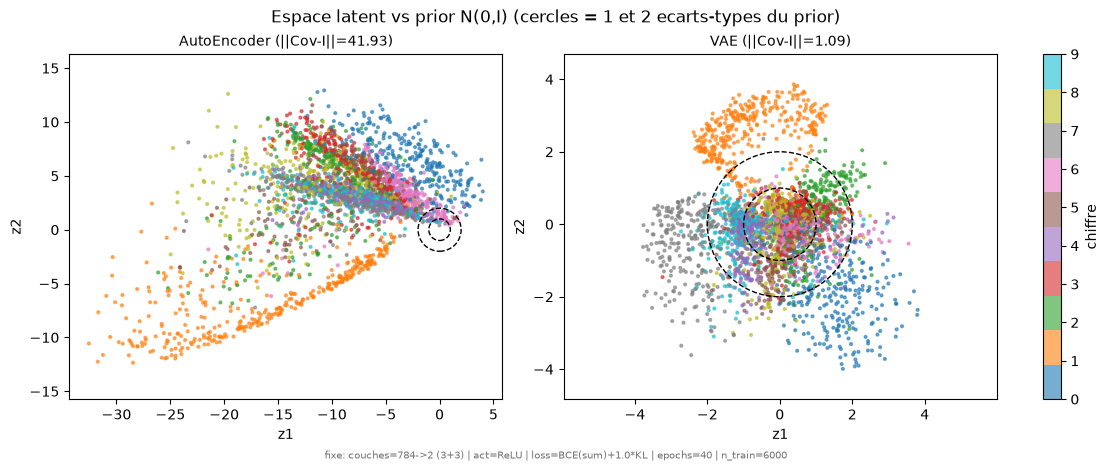

In [6]:
vae_stats = posterior_stats(vae_model, X_mnist_eval)
ae_centre, ae_gap = prior_gap(ae_latent.array)
vae_centre, vae_gap = prior_gap(vae_stats["mu"])

print(f"{'':>12} | {'||E[mu]||':>10} | {'||Cov-I||_F':>12}")
print(f"{'AutoEncoder':>12} | {ae_centre:>10.3f} | {ae_gap:>12.3f}")
print(f"{'VAE':>12} | {vae_centre:>10.3f} | {vae_gap:>12.3f}")
print(f"\nKL du VAE: {vae_stats['kl_total']:.3f} nats | par dimension: {np.round(vae_stats['kl_per_dim'], 3)}")
print(f"sigma par dimension: {np.round(vae_stats['sigma'].mean(axis=0), 3)} "
      f"(le prior impose 1.0; plus petit = la dimension transporte de l'information)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout="constrained")
for ax, (nom, codes, ecart) in zip(axes, [("AutoEncoder", ae_latent.array, ae_gap),
                                          ("VAE", vae_stats["mu"], vae_gap)]):
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    for rayon in (1, 2):
        ax.add_patch(plt.Circle((0, 0), rayon, fill=False, color="black", linestyle="--", zorder=5))
    ax.set_title(f"{nom} (||Cov-I||={ecart:.2f})", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
    ax.set_aspect("equal", adjustable="datalim")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
finish_figure(fig, "Espace latent vs prior N(0,I) (cercles = 1 et 2 ecarts-types du prior)",
              VAE_NOTE, layout=False)

### Preuve 2/2 : generer sans rien ajuster

C'est la figure centrale. Deux facons d'echantillonner: la gaussienne ajustee sur les codes (le
pis-aller de `03`), et le prior `N(0,I)` tire sans regarder les donnees. Pour l'AE la ligne
"prior" doit etre du bruit; pour le VAE les deux lignes doivent se ressembler.

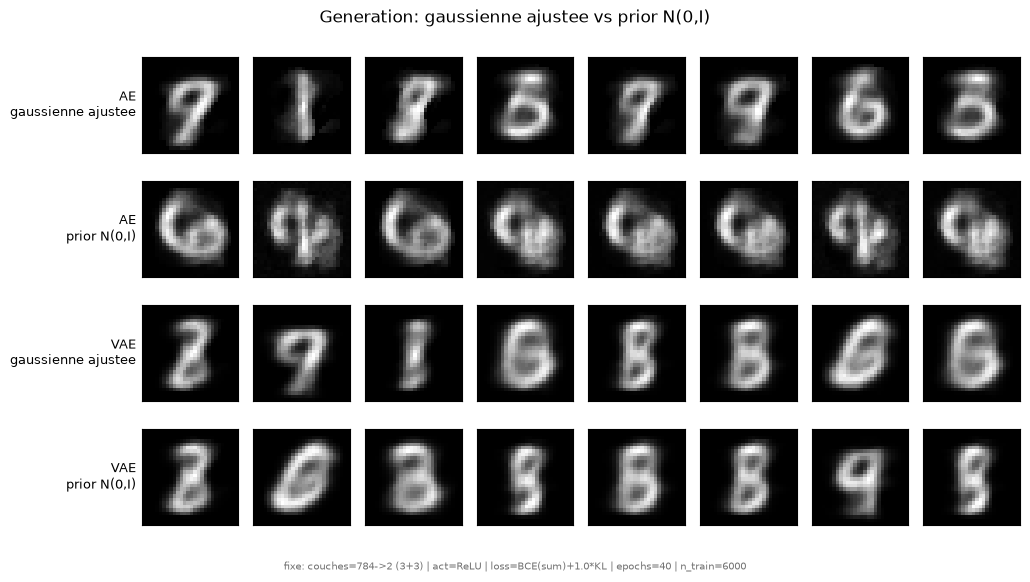

  AE | tirages N(0,I) dans la zone occupee par les codes: 100.0%
 VAE | tirages N(0,I) dans la zone occupee par les codes: 100.0%


In [7]:
lignes, etiquettes = [], []
for nom, modele, latent in [("AE", ae_model, ae_latent), ("VAE", vae_model, vae_latent)]:
    lignes.append(generate_from_latent_using_gaussian(modele, latent, 8, seed=1))
    etiquettes.append(f"{nom}\ngaussienne ajustee")
    if nom == "VAE":
        codes = modele.sample_prior(8, seed=1)
    else:
        # L'AE n'a pas de prior: on lui applique N(0,I) quand meme, pour montrer que rien ne l'y attache.
        rng = np.random.default_rng(1)
        codes = Latent(array=rng.standard_normal((8, 2)).astype(np.float32), nature="continuous")
    lignes.append(modele.decode(codes))
    etiquettes.append(f"{nom}\nprior N(0,I)")

show_labeled_image_rows(lignes, MNIST_SHAPE, etiquettes, n=8,
                        title="Generation: gaussienne ajustee vs prior N(0,I)", config=VAE_NOTE)

# Chiffre a l'appui: quelle part des tirages N(0,I) tombe dans la zone occupee par les codes ?
rng = np.random.default_rng(0)
tirages = rng.standard_normal((2000, 2)).astype(np.float32)
for nom, codes in [("AE", ae_latent.array), ("VAE", vae_stats["mu"])]:
    lo, hi = codes.min(axis=0), codes.max(axis=0)
    dedans = np.mean(np.all((tirages >= lo) & (tirages <= hi), axis=1))
    print(f"{nom:>4} | tirages N(0,I) dans la zone occupee par les codes: {100 * dedans:5.1f}%")

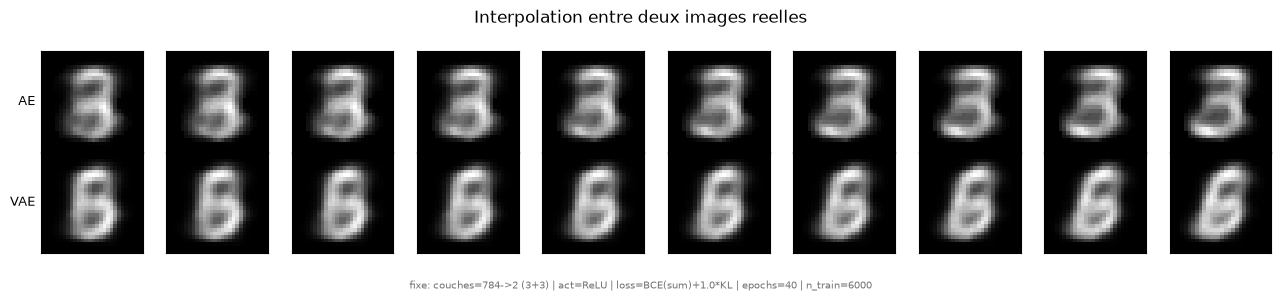

In [8]:
lignes = []
for modele, latent in [(ae_model, ae_latent), (vae_model, vae_latent)]:
    chemin = interpolate_latent(latent.array[0], latent.array[1], steps=10)
    lignes.append(modele.decode(Latent(array=chemin, nature="continuous")))

show_labeled_image_rows(lignes, MNIST_SHAPE, ["AE", "VAE"], n=10,
                        title="Interpolation entre deux images reelles", config=VAE_NOTE)

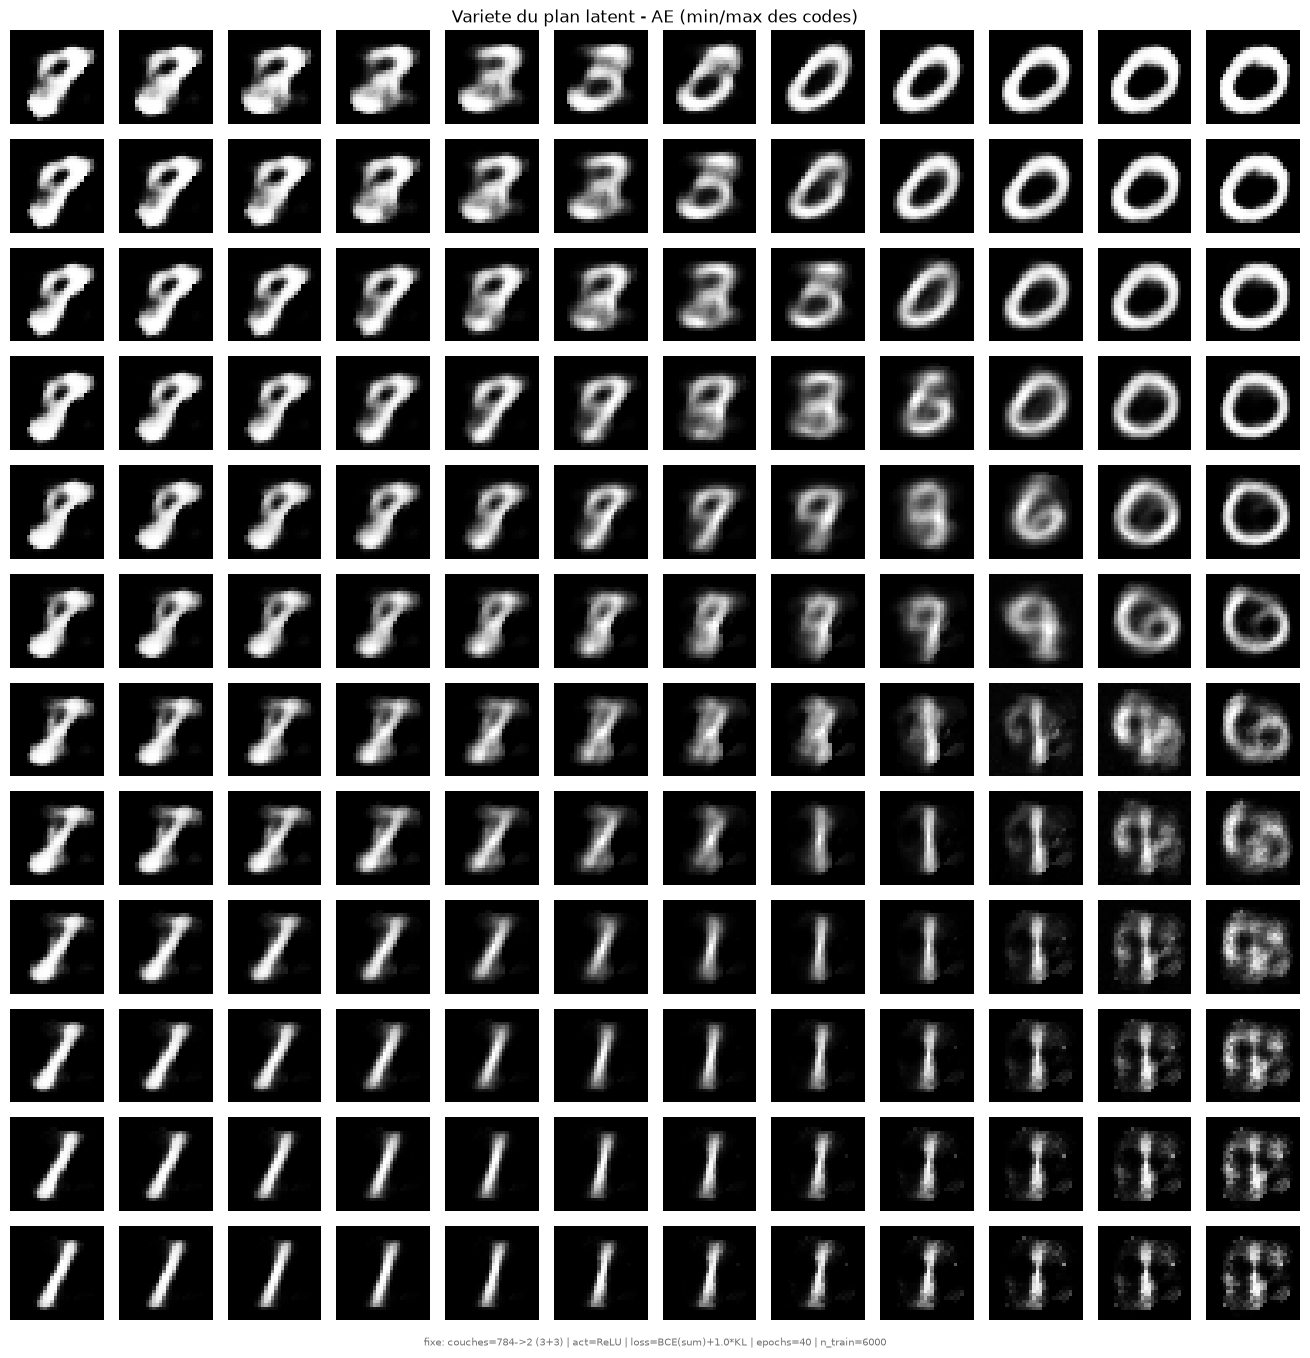

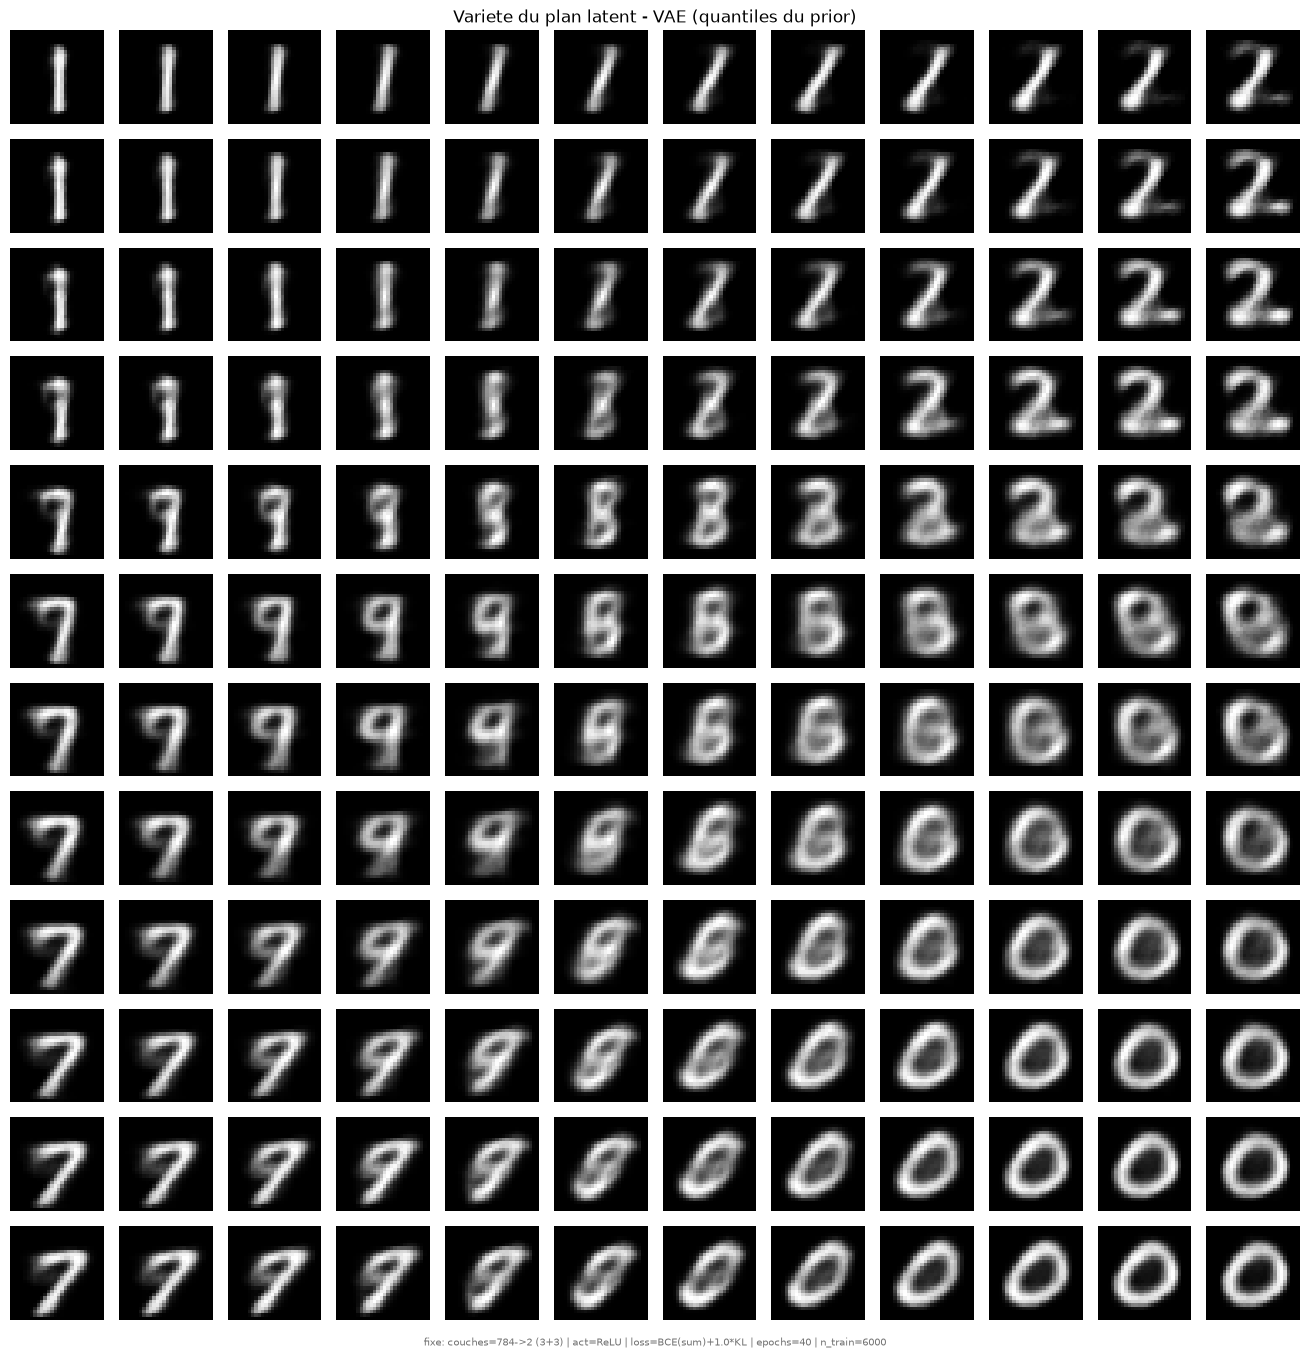

In [9]:
# La grille du VAE se lit sur les quantiles du prior (+/- 2.5 ecarts-types ~ 99% de sa masse):
# on sait d'avance ou regarder. L'AE n'a que la boite englobante de ses codes.
n = 12
lo, hi = ae_latent.array.min(axis=0), ae_latent.array.max(axis=0)
grilles = {
    "AE (min/max des codes)": (np.linspace(lo[0], hi[0], n), np.linspace(hi[1], lo[1], n), ae_model),
    "VAE (quantiles du prior)": (np.linspace(-2.5, 2.5, n), np.linspace(2.5, -2.5, n), vae_model),
}
for nom, (xs, ys, modele) in grilles.items():
    grille = np.array([[x, y] for y in ys for x in xs], dtype=np.float32)
    show_image_grid(modele.decode(Latent(array=grille, nature="continuous")),
                    MNIST_SHAPE, nrow=n, ncol=n,
                    title=f"Variete du plan latent - {nom}", config=VAE_NOTE)

## Le piege de la reduction est un bug beta=784

`nn.BCELoss()` moyenne par defaut sur le batch **et sur les 784 pixels**, alors que le KL somme
sur les dimensions latentes: la reconstruction est donc 784x trop petite. Comme Adam est
invariant d'echelle, seul le rapport reconstruction/KL compte, et
`recon_mean + 1*KL` revient exactement a `recon_sum + 784*KL`.

**Utiliser `reduction="mean"`, c'est donc entrainer avec beta=784.** Le KL ecrase tout, l'encodeur
renonce a encoder et rend le prior tel quel: mu -> 0, sigma -> 1, KL -> 0. C'est le posterior
collapse, et c'est pourquoi `VariationalAutoEncoder.fit` force `reduction="sum"`. On le reproduit
ici via beta=784, ce qui prouve l'equivalence.

           |  KL total |               mu.std |              sigma | dims actives
    beta=1 |    5.1956 |      [1.2969 1.335 ] |      [0.123 0.122] |            2
  beta=784 |    0.0000 |      [0.0015 0.0028] |            [1. 1.] |            0


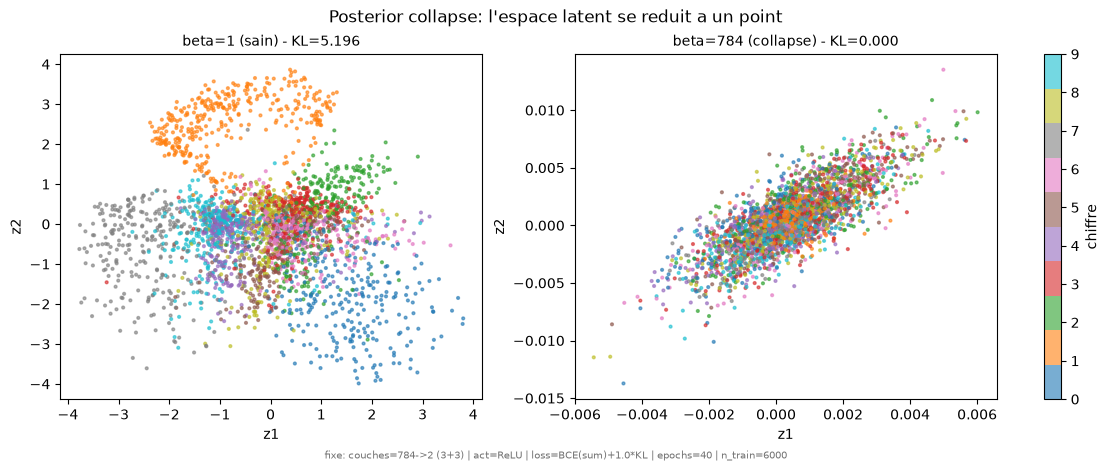

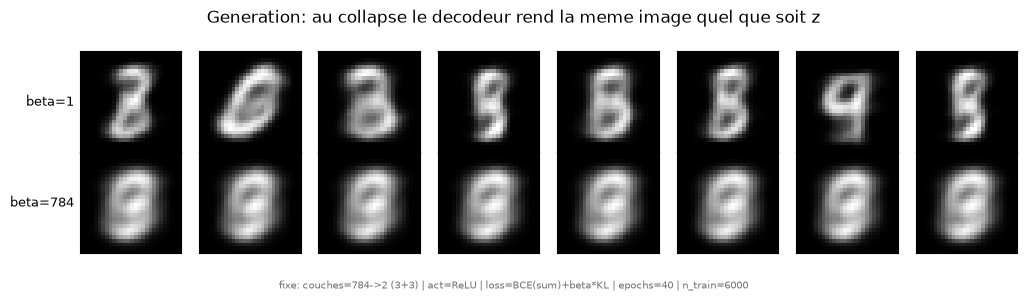

In [10]:
BETA_COLLAPSE = 784.0   # == reduction="mean" avec beta=1

collapse_run = run_vae(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS_SWEEP,
                       beta=BETA_COLLAPSE, seed=GRAINE)
collapse_stats = posterior_stats(collapse_run["model"], X_mnist_eval)

print(f"{'':>10} | {'KL total':>9} | {'mu.std':>20} | {'sigma':>18} | {'dims actives':>12}")
for nom, stats in [("beta=1", vae_stats), (f"beta={BETA_COLLAPSE:.0f}", collapse_stats)]:
    print(f"{nom:>10} | {stats['kl_total']:>9.4f} | {str(np.round(stats['mu'].std(axis=0), 4)):>20} "
          f"| {str(np.round(stats['sigma'].mean(axis=0), 3)):>18} | {stats['dims_actives']:>12}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), layout="constrained")
for ax, (nom, stats) in zip(axes, [("beta=1 (sain)", vae_stats),
                                   (f"beta={BETA_COLLAPSE:.0f} (collapse)", collapse_stats)]):
    codes = stats["mu"]
    scatter = ax.scatter(codes[:, 0], codes[:, 1], c=y_mnist_eval, cmap="tab10", s=4, alpha=0.6)
    ax.set_title(f"{nom} - KL={stats['kl_total']:.3f}", fontsize=10)
    ax.set_xlabel("z1"); ax.set_ylabel("z2")
fig.colorbar(scatter, ax=list(axes), label="chiffre")
finish_figure(fig, "Posterior collapse: l'espace latent se reduit a un point", VAE_NOTE, layout=False)

show_labeled_image_rows(
    [vae_model.decode(vae_model.sample_prior(8, seed=1)),
     collapse_run["model"].decode(collapse_run["model"].sample_prior(8, seed=1))],
    MNIST_SHAPE, ["beta=1", f"beta={BETA_COLLAPSE:.0f}"], n=8,
    title="Generation: au collapse le decodeur rend la meme image quel que soit z",
    config=note(couches="784->2 (3+3)", act="ReLU", loss="BCE(sum)+beta*KL",
                epochs=EPOCHS_SWEEP, n_train=len(X_tr)),
)

## Experimentation - beta

`beta` arbitre entre fidelite et conformite au prior. beta=0: plus aucune pression, le latent
redevient un nuage libre comme celui d'un AE. beta=1: l'ELBO standard. beta>1: on paie de la
fidelite pour un latent plus propre, des dimensions commencent a mourir. beta=784: le bug de la
reduction.

Attention a `||Cov(mu) - I||`: elle porte sur les `mu`, pas sur les `z` tires. Au collapse
`mu -> 0` donc `Cov(mu) -> 0` et l'ecart tend vers `||0 - I|| = sqrt(latent_dim)`, soit 1.414 a
latent 2. Ce n'est donc pas un mauvais accord au prior mais le plancher de la mesure quand mu ne
transporte plus rien. C'est le nombre de dimensions actives qui tranche.

  beta |  MSE eval |  KL total |  ||Cov-I|| | dims actives
   0.0 |    0.0480 |   81.2706 |     58.385 |            2
   0.1 |    0.0477 |   11.4266 |      6.356 |            2
   0.5 |    0.0481 |    6.4277 |      1.835 |            2
   1.0 |    0.0482 |    5.1956 |      1.090 |            2
   4.0 |    0.0491 |    2.9344 |      0.143 |            2
  10.0 |    0.0522 |    1.5349 |      0.351 |            2
 784.0 |    0.0671 |    0.0000 |      1.414 |            0


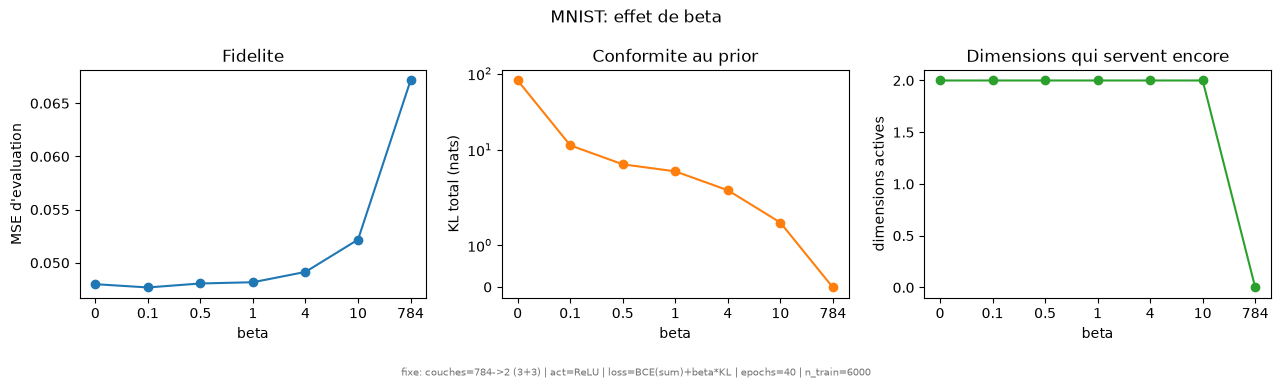

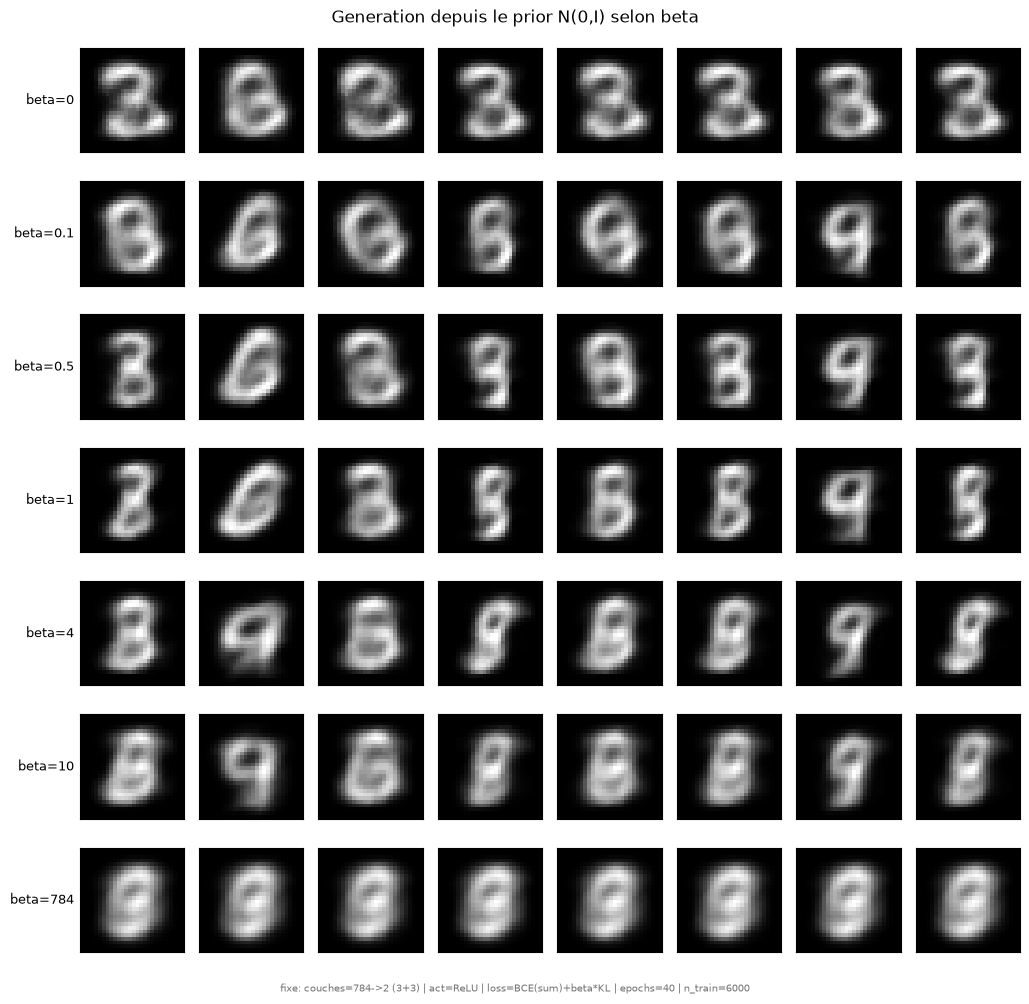

In [11]:
BETAS = [0.0, 0.1, 0.5, 1.0, 4.0, 10.0, 784.0]

beta_runs = {}
print(f"{'beta':>6} | {'MSE eval':>9} | {'KL total':>9} | {'||Cov-I||':>10} | {'dims actives':>12}")
for beta in BETAS:
    run = run_vae(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS_SWEEP, beta=beta, seed=GRAINE)
    stats = posterior_stats(run["model"], X_mnist_eval)
    _, ecart = prior_gap(stats["mu"])
    beta_runs[beta] = {"run": run, "stats": stats, "gap": ecart}
    print(f"{beta:>6.1f} | {run['report']['reconstruction_mse']:>9.4f} | {stats['kl_total']:>9.4f} "
          f"| {ecart:>10.3f} | {stats['dims_actives']:>12}")

BETA_NOTE = note(couches="784->2 (3+3)", act="ReLU", loss="BCE(sum)+beta*KL",
                 epochs=EPOCHS_SWEEP, n_train=len(X_tr))
x = np.arange(len(BETAS))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(x, [beta_runs[b]["run"]["report"]["reconstruction_mse"] for b in BETAS], marker="o")
axes[0].set_ylabel("MSE d'evaluation"); axes[0].set_title("Fidelite")
axes[1].plot(x, [beta_runs[b]["stats"]["kl_total"] for b in BETAS], marker="o", color="tab:orange")
axes[1].set_ylabel("KL total (nats)"); axes[1].set_yscale("symlog"); axes[1].set_title("Conformite au prior")
axes[2].plot(x, [beta_runs[b]["stats"]["dims_actives"] for b in BETAS], marker="o", color="tab:green")
axes[2].set_ylabel("dimensions actives"); axes[2].set_title("Dimensions qui servent encore")
for ax in axes:
    ax.set_xticks(x, [f"{b:g}" for b in BETAS]); ax.set_xlabel("beta")
finish_figure(fig, "MNIST: effet de beta", BETA_NOTE)

show_labeled_image_rows(
    [beta_runs[b]["run"]["model"].decode(beta_runs[b]["run"]["model"].sample_prior(8, seed=1))
     for b in BETAS],
    MNIST_SHAPE, [f"beta={b:g}" for b in BETAS], n=8,
    title="Generation depuis le prior N(0,I) selon beta", config=BETA_NOTE,
)

## Experimentation - dimension latente et collapse

Meme balayage que `03`, avec deux axes en plus que seul un VAE possede: le KL et le nombre de
dimensions actives. Cela explique pourquoi la MSE d'un VAE sature quand on agrandit le latent:
les dimensions en trop collapsent et ne servent tout simplement pas.

latent |  MSE eval |  KL total | dims actives |   ratio
     2 |    0.0482 |     5.196 |    2 / 2     |   25.48
     8 |    0.0265 |    13.189 |    7 / 8     |   14.28
    16 |    0.0210 |    16.631 |   16 / 16    |   10.22
    32 |    0.0191 |    17.878 |   27 / 32    |    7.01
    64 |    0.0189 |    16.573 |   33 / 64    |    4.53


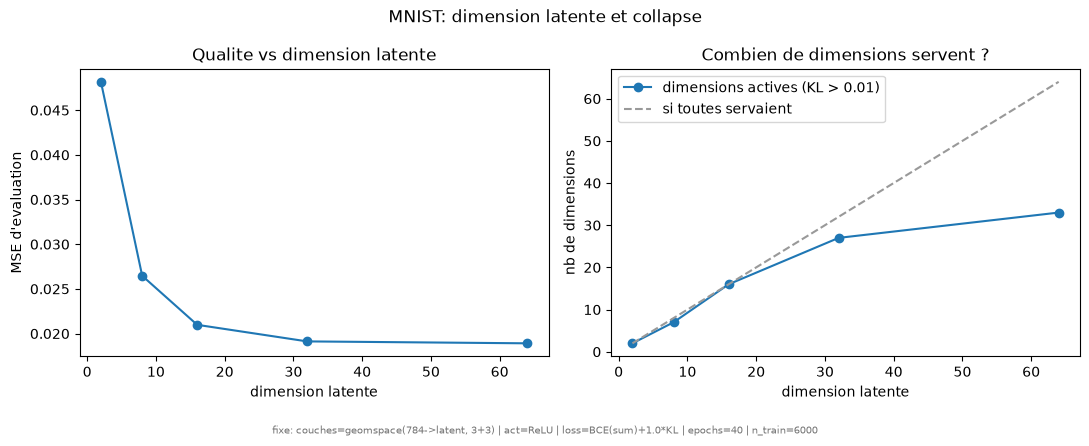

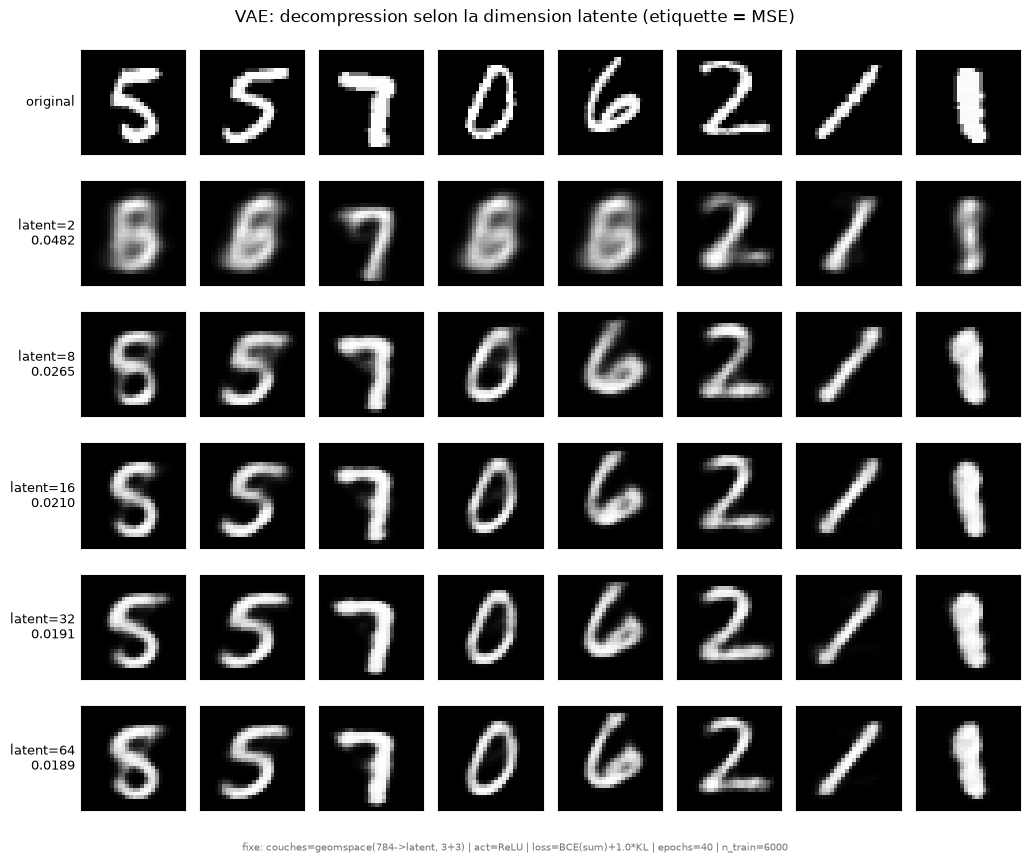

In [12]:
latent_dims = [2, 8, 16, 32, 64]

vae_latent_runs = {}
print(f"{'latent':>6} | {'MSE eval':>9} | {'KL total':>9} | {'dims actives':>12} | {'ratio':>7}")
for latent_dim in latent_dims:
    run = run_vae(X_tr, X_mnist_eval, 784, latent_dim, nn.ReLU, EPOCHS_SWEEP, beta=1.0, seed=GRAINE)
    stats = posterior_stats(run["model"], X_mnist_eval)
    vae_latent_runs[latent_dim] = {"run": run, "stats": stats}
    print(f"{latent_dim:>6} | {run['report']['reconstruction_mse']:>9.4f} | {stats['kl_total']:>9.3f} "
          f"| {stats['dims_actives']:>4} / {latent_dim:<5} | {run['report']['compression_ratio']:>7.2f}")

LATENT_NOTE = note(couches="geomspace(784->latent, 3+3)", act="ReLU", loss="BCE(sum)+1.0*KL",
                   epochs=EPOCHS_SWEEP, n_train=len(X_tr))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(latent_dims, [vae_latent_runs[d]["run"]["report"]["reconstruction_mse"] for d in latent_dims],
             marker="o")
axes[0].set_xlabel("dimension latente"); axes[0].set_ylabel("MSE d'evaluation")
axes[0].set_title("Qualite vs dimension latente")
axes[1].plot(latent_dims, [vae_latent_runs[d]["stats"]["dims_actives"] for d in latent_dims],
             marker="o", label="dimensions actives (KL > 0.01)")
axes[1].plot(latent_dims, latent_dims, linestyle="--", color="0.6", label="si toutes servaient")
axes[1].set_xlabel("dimension latente"); axes[1].set_ylabel("nb de dimensions")
axes[1].set_title("Combien de dimensions servent ?"); axes[1].legend()
finish_figure(fig, "MNIST: dimension latente et collapse", LATENT_NOTE)

show_labeled_image_rows(
    [X_mnist_eval] + [vae_latent_runs[d]["run"]["reconstruction"] for d in latent_dims],
    MNIST_SHAPE,
    ["original"] + [f"latent={d}\n{vae_latent_runs[d]['run']['report']['reconstruction_mse']:.4f}"
                    for d in latent_dims],
    n=8, title="VAE: decompression selon la dimension latente (etiquette = MSE)", config=LATENT_NOTE,
)

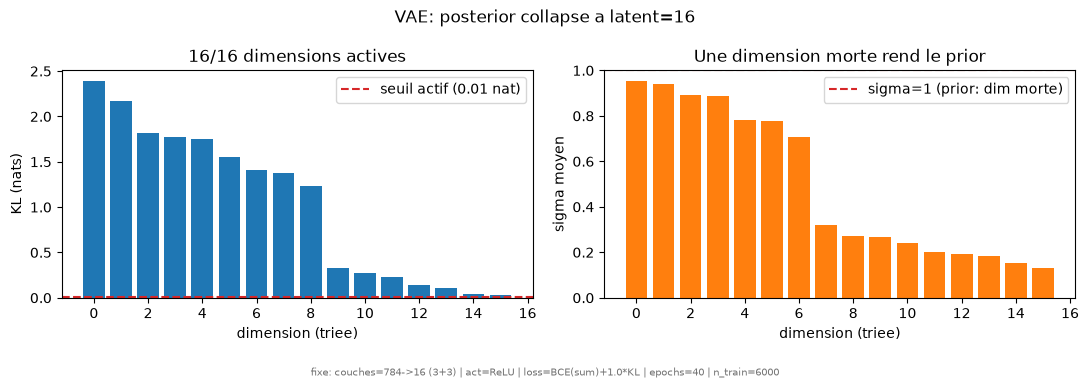

In [13]:
# Le collapse rendu visible: KL dimension par dimension, a latent 16.
stats16 = vae_latent_runs[16]["stats"]
kl_tri = np.sort(stats16["kl_per_dim"])[::-1]
sigma_tri = np.sort(stats16["sigma"].mean(axis=0))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(range(16), kl_tri, color=["tab:blue" if k > 0.01 else "0.7" for k in kl_tri])
axes[0].axhline(0.01, color="tab:red", linestyle="--", label="seuil actif (0.01 nat)")
axes[0].set_xlabel("dimension (triee)"); axes[0].set_ylabel("KL (nats)")
axes[0].set_title(f"{stats16['dims_actives']}/16 dimensions actives"); axes[0].legend()
axes[1].bar(range(16), sigma_tri, color="tab:orange")
axes[1].axhline(1.0, color="tab:red", linestyle="--", label="sigma=1 (prior: dim morte)")
axes[1].set_xlabel("dimension (triee)"); axes[1].set_ylabel("sigma moyen")
axes[1].set_title("Une dimension morte rend le prior"); axes[1].legend()
finish_figure(fig, "VAE: posterior collapse a latent=16",
              note(couches="784->16 (3+3)", act="ReLU", loss="BCE(sum)+1.0*KL",
                   epochs=EPOCHS_SWEEP, n_train=len(X_tr)))

## Experimentation - perte x activation de sortie

Meme matrice que `03`, memes deux cases impossibles: le garde-fou BCE vient du meme decodeur.
Rappel VAE: la reconstruction est sommee sur les dimensions, sinon on retombe sur le collapse.

out_act= Sigmoid | perte=MSE | MSE=0.0267 | KL=  8.428
out_act= Sigmoid | perte=L1  | MSE=0.0492 | KL=  8.238
out_act= Sigmoid | perte=BCE | MSE=0.0191 | KL= 17.878
out_act=    ReLU | perte=MSE | MSE=0.0255 | KL=  9.144
out_act=    ReLU | perte=L1  | MSE=0.0544 | KL=  8.012
out_act=    ReLU | perte=BCE | INVALIDE (sortie non bornee + BCE)
out_act=  aucune | perte=MSE | MSE=0.0284 | KL=  8.019
out_act=  aucune | perte=L1  | MSE=0.0736 | KL=  1.827
out_act=  aucune | perte=BCE | INVALIDE (sortie non bornee + BCE)


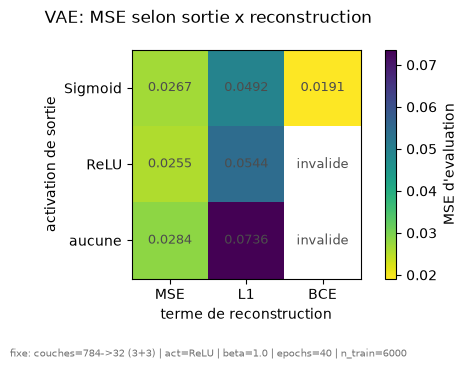

In [14]:
loss_functions = {"MSE": nn.MSELoss, "L1": nn.L1Loss, "BCE": nn.BCELoss}
output_activations = {"Sigmoid": nn.Sigmoid, "ReLU": nn.ReLU, "aucune": None}
INVALIDES = {("ReLU", "BCE"), ("aucune", "BCE")}

vae_out_loss = {}
for out_name, out_act in output_activations.items():
    for loss_name, loss_cls in loss_functions.items():
        if (out_name, loss_name) in INVALIDES:
            print(f"out_act={out_name:>8} | perte={loss_name:<3} | INVALIDE (sortie non bornee + BCE)")
            continue
        run = run_vae(X_tr, X_mnist_eval, 784, 32, nn.ReLU, EPOCHS_SWEEP,
                      loss_function=loss_cls, output_activation=out_act, beta=1.0, seed=GRAINE)
        stats = posterior_stats(run["model"], X_mnist_eval)
        vae_out_loss[(out_name, loss_name)] = run
        print(f"out_act={out_name:>8} | perte={loss_name:<3} "
              f"| MSE={run['report']['reconstruction_mse']:.4f} | KL={stats['kl_total']:>7.3f}")

# Les cases invalides restent a NaN: imshow les laisse blanches.
matrice = np.full((3, 3), np.nan)
for i, out_name in enumerate(output_activations):
    for j, loss_name in enumerate(loss_functions):
        if (out_name, loss_name) in vae_out_loss:
            matrice[i, j] = vae_out_loss[(out_name, loss_name)]["report"]["reconstruction_mse"]

fig, ax = plt.subplots(figsize=(5.5, 3.6))
image = ax.imshow(matrice, cmap="viridis_r")
ax.set_xticks(range(3), list(loss_functions)); ax.set_yticks(range(3), list(output_activations))
ax.set_xlabel("terme de reconstruction"); ax.set_ylabel("activation de sortie")
for i in range(3):
    for j in range(3):
        texte = "invalide" if np.isnan(matrice[i, j]) else f"{matrice[i, j]:.4f}"
        ax.text(j, i, texte, ha="center", va="center", fontsize=9, color="0.3")
fig.colorbar(image, ax=ax, label="MSE d'evaluation")
finish_figure(fig, "VAE: MSE selon sortie x reconstruction",
              note(couches="784->32 (3+3)", act="ReLU", beta=1.0, epochs=EPOCHS_SWEEP, n_train=len(X_tr)))

## Experimentation - nombre d'epochs

Comme dans `03`, chaque budget entraine un modele independant. En plus: on suit reconstruction et
KL separement, car ils ne progressent pas ensemble - le KL monte souvent d'abord, puis se
stabilise pendant que la reconstruction continue de descendre.

epochs | MSE train |  MSE eval |  KL total
     5 |    0.0588 |    0.0582 |     4.591
    10 |    0.0553 |    0.0546 |     4.364
    20 |    0.0515 |    0.0510 |     4.549
    40 |    0.0481 |    0.0482 |     5.196
    80 |    0.0445 |    0.0458 |     5.596


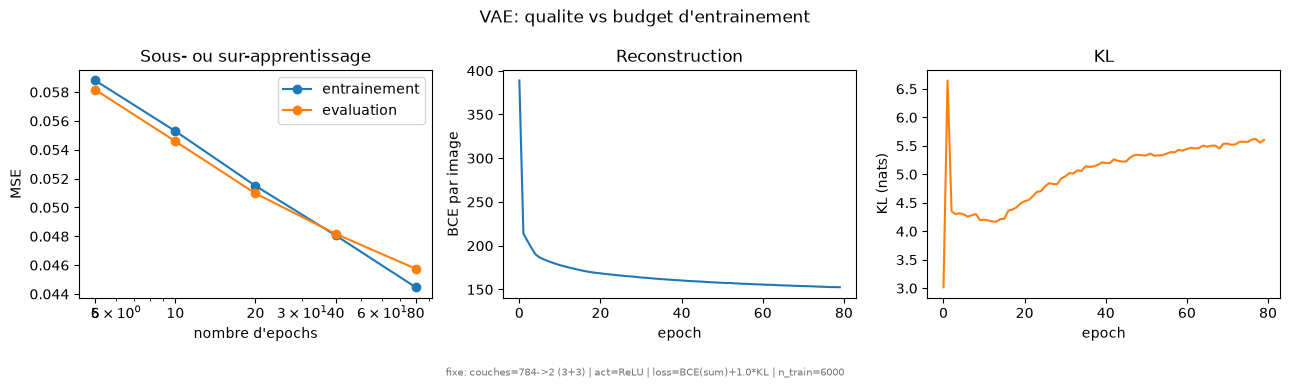

In [15]:
EPOCH_BUDGETS = [5, 10, 20, 40, 80]

vae_epoch_runs = {}
print(f"{'epochs':>6} | {'MSE train':>9} | {'MSE eval':>9} | {'KL total':>9}")
for budget in EPOCH_BUDGETS:
    run = run_vae(X_tr, X_mnist_eval, 784, 2, nn.ReLU, budget, beta=1.0, seed=GRAINE)
    train_rec = run["model"].decode(run["model"].encode(X_tr))
    run["train_mse"] = float(np.mean((X_tr - train_rec) ** 2))
    stats = posterior_stats(run["model"], X_mnist_eval)
    vae_epoch_runs[budget] = {"run": run, "stats": stats}
    print(f"{budget:>6} | {run['train_mse']:>9.4f} | {run['report']['reconstruction_mse']:>9.4f} "
          f"| {stats['kl_total']:>9.3f}")

EPOCH_NOTE = note(couches="784->2 (3+3)", act="ReLU", loss="BCE(sum)+1.0*KL", n_train=len(X_tr))
plus_long = vae_epoch_runs[EPOCH_BUDGETS[-1]]["run"]["model"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(EPOCH_BUDGETS, [vae_epoch_runs[b]["run"]["train_mse"] for b in EPOCH_BUDGETS],
             marker="o", label="entrainement")
axes[0].plot(EPOCH_BUDGETS, [vae_epoch_runs[b]["run"]["report"]["reconstruction_mse"] for b in EPOCH_BUDGETS],
             marker="o", label="evaluation")
axes[0].set_xscale("log"); axes[0].set_xticks(EPOCH_BUDGETS, [str(b) for b in EPOCH_BUDGETS])
axes[0].set_xlabel("nombre d'epochs"); axes[0].set_ylabel("MSE"); axes[0].legend()
axes[0].set_title("Sous- ou sur-apprentissage")
axes[1].plot(plus_long.recon_history, color="tab:blue")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("BCE par image"); axes[1].set_title("Reconstruction")
axes[2].plot(plus_long.kl_history, color="tab:orange")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("KL (nats)"); axes[2].set_title("KL")
finish_figure(fig, "VAE: qualite vs budget d'entrainement", EPOCH_NOTE)

## Experimentation - profondeur du reseau a latent fixe

Meme protocole que `03`: latent fixe a 2, profondeur de 1 a 6, 3 graines. A d=1 le tronc de
l'encodeur est vide et les deux tetes lisent directement les 784 pixels.

d=1 | MSE=0.0619 +/- 0.0008 | KL=10.842 | codebook=    9,408 o | ratio=281.61
d=2 | MSE=0.0509 +/- 0.0001 | KL= 4.854 | codebook=  125,908 o | ratio= 62.76
d=3 | MSE=0.0486 +/- 0.0004 | KL= 4.998 | codebook=  345,276 o | ratio= 25.48
d=4 | MSE=0.0471 +/- 0.0007 | KL= 5.102 | codebook=  584,732 o | ratio= 15.46
d=5 | MSE=0.0554 +/- 0.0086 | KL= 2.882 | codebook=  821,532 o | ratio= 11.13
d=6 | MSE=0.0475 +/- 0.0027 | KL= 4.700 | codebook=1,054,144 o | ratio=  8.73

Meilleure profondeur: d=4


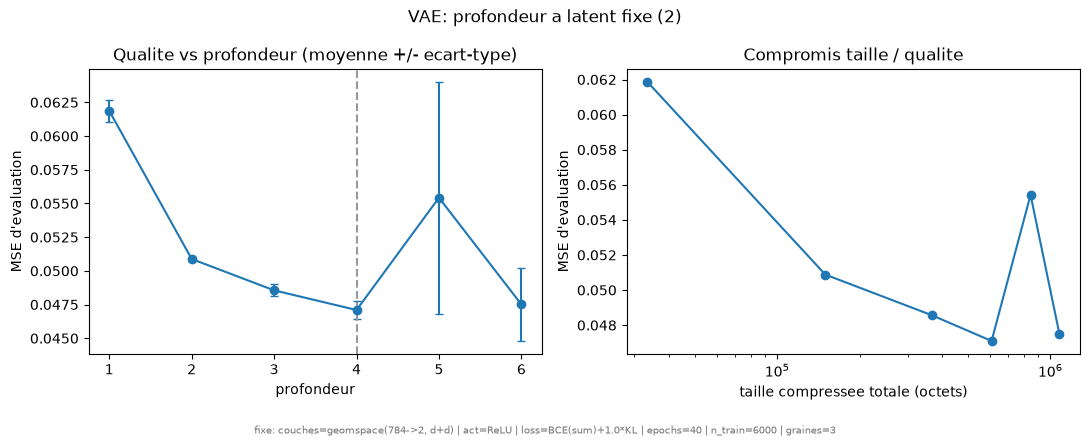

In [16]:
DEPTHS = [1, 2, 3, 4, 5, 6]
SEEDS = [0, 1, 2]

vae_depth = {}
for depth in DEPTHS:
    mses, kls = [], []
    for seed in SEEDS:
        run = run_vae(X_tr, X_mnist_eval, 784, 2, nn.ReLU, EPOCHS_SWEEP, beta=1.0,
                      seed=seed, n_layers=depth)
        mses.append(run["report"]["reconstruction_mse"])
        kls.append(posterior_stats(run["model"], X_mnist_eval)["kl_total"])
    vae_depth[depth] = {
        "mse": float(np.mean(mses)), "ecart": float(np.std(mses)), "kl": float(np.mean(kls)),
        "codebook": run["report"]["codebook_bytes"], "total": run["report"]["total_compressed_bytes"],
        "ratio": run["report"]["compression_ratio"],
    }
    r = vae_depth[depth]
    print(f"d={depth} | MSE={r['mse']:.4f} +/- {r['ecart']:.4f} | KL={r['kl']:>6.3f} "
          f"| codebook={r['codebook']:>9,} o | ratio={r['ratio']:6.2f}")

meilleure = min(DEPTHS, key=lambda d: vae_depth[d]["mse"])
print(f"\nMeilleure profondeur: d={meilleure}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].errorbar(DEPTHS, [vae_depth[d]["mse"] for d in DEPTHS],
                 yerr=[vae_depth[d]["ecart"] for d in DEPTHS], marker="o", capsize=3)
axes[0].axvline(meilleure, color="0.6", linestyle="--")
axes[0].set_xlabel("profondeur"); axes[0].set_ylabel("MSE d'evaluation")
axes[0].set_title("Qualite vs profondeur (moyenne +/- ecart-type)")
axes[1].plot([vae_depth[d]["total"] for d in DEPTHS], [vae_depth[d]["mse"] for d in DEPTHS], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("taille compressee totale (octets)"); axes[1].set_ylabel("MSE d'evaluation")
axes[1].set_title("Compromis taille / qualite")
finish_figure(fig, "VAE: profondeur a latent fixe (2)",
              note(couches="geomspace(784->2, d+d)", act="ReLU", loss="BCE(sum)+1.0*KL",
                   epochs=EPOCHS_SWEEP, n_train=len(X_tr), graines=len(SEEDS)))

## Pourquoi il n'y a pas d'experience sur l'activation latente

`03` fait varier `latent_activation`; le VAE ne l'expose pas, car `mu` n'est pas un code mais un
parametre de distribution que le KL compare a `N(0,I)`. Le borner revient a se battre contre le KL:
`Sigmoid(mu)` dans (0,1) ne peut jamais coincider avec `N(0,1)`, et `ReLU(mu) >= 0` rend la moitie
du prior inatteignable alors que `sample_prior` y tire.

Le masque de neurones morts de `03` n'est pas repris non plus: il porte sur le decodeur, qui est
le meme objet ici.

## Partie B - shapes

train: (12000, 3072) | eval: (3000, 3072) | classes: ['circle', 'square', 'triangle', 'cross', 'star', 'bar']
           latent_nature: continuous
          codebook_bytes: 3306708
            latent_bytes: 24000
  total_compressed_bytes: 3330708
          original_bytes: 36864000
       compression_ratio: 11.0679
      reconstruction_mse: 0.0284
||E[mu]||=0.644 | ||Cov-I||=0.783 | KL=6.011


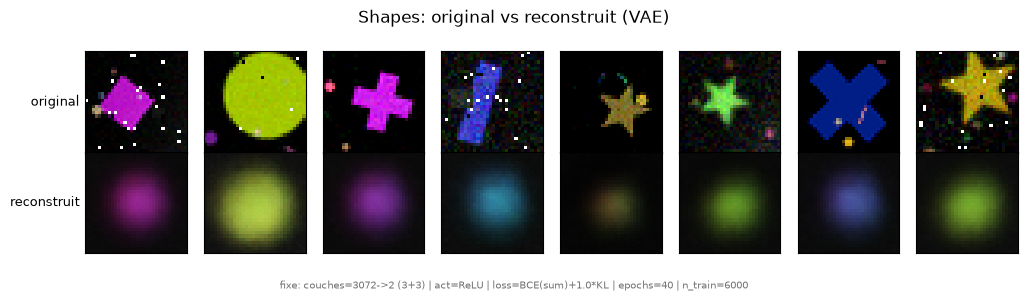

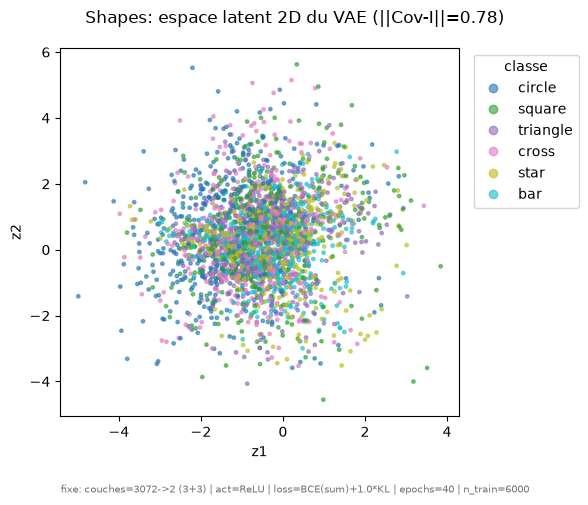

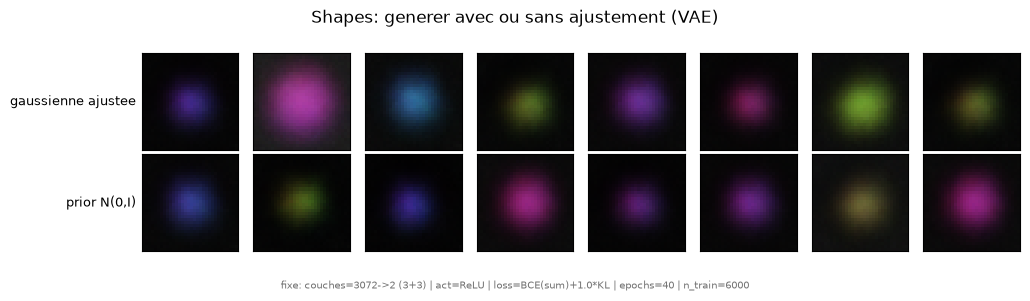

In [18]:
X_shapes_train, y_shapes_train, shape_names = load_shapes_npz(split="train", max_samples=12000)
X_shapes_eval, y_shapes_eval, _ = load_shapes_npz(split="validation", max_samples=3000)
X_shapes_train = X_shapes_train.reshape(len(X_shapes_train), -1)
X_shapes_eval = X_shapes_eval.reshape(len(X_shapes_eval), -1)

SHAPES_SHAPE = (3, 32, 32)
SHAPES_DIM = 3 * 32 * 32
X_shapes_tr, _ = subsample_dataset(X_shapes_train, y_shapes_train, 6000, seed=1)
print("train:", X_shapes_train.shape, "| eval:", X_shapes_eval.shape, "| classes:", shape_names)

shapes_run = run_vae(X_shapes_tr, X_shapes_eval, SHAPES_DIM, 2, nn.ReLU, EPOCHS, beta=1.0, seed=GRAINE)
shapes_vae = shapes_run["model"]
shapes_stats = posterior_stats(shapes_vae, X_shapes_eval)
shapes_centre, shapes_gap = prior_gap(shapes_stats["mu"])

print_compression_report(shapes_run["report"])
print(f"||E[mu]||={shapes_centre:.3f} | ||Cov-I||={shapes_gap:.3f} | KL={shapes_stats['kl_total']:.3f}")

SHAPES_NOTE = note(couches=f"{SHAPES_DIM}->2 (3+3)", act="ReLU", loss="BCE(sum)+1.0*KL",
                   epochs=EPOCHS, n_train=len(X_shapes_tr))

show_labeled_image_rows(
    [X_shapes_eval, shapes_run["reconstruction"]], SHAPES_SHAPE, ["original", "reconstruit"], n=8,
    title="Shapes: original vs reconstruit (VAE)", config=SHAPES_NOTE,
)

plot_latent_scatter(shapes_stats["mu"], y_shapes_eval, class_names=shape_names,
                    title=f"Shapes: espace latent 2D du VAE (||Cov-I||={shapes_gap:.2f})",
                    config=SHAPES_NOTE)

show_labeled_image_rows(
    [generate_from_latent_using_gaussian(shapes_vae, shapes_run["latent"], 8, seed=1),
     shapes_vae.decode(shapes_vae.sample_prior(8, seed=1))],
    SHAPES_SHAPE, ["gaussienne ajustee", "prior N(0,I)"], n=8,
    title="Shapes: generer avec ou sans ajustement (VAE)", config=SHAPES_NOTE,
)

## Reponses aux questions du projet

**1. Nature de l'espace latent.**

Continu, comme pour l'AutoEncoder (`encode` renvoie un `Latent` de nature `"continuous"`), mais
avec une difference decisive: sa **loi est connue d'avance**. L'encodeur ne rend pas un point
mais une distribution `q(z|x) = N(mu, diag(exp(logvar)))`, et le terme KL la contraint a
ressembler au prior `N(0, I)`. La ou l'AutoEncoder produisait un nuage de forme et d'echelle
arbitraires - qu'il fallait mesurer apres coup pour esperer y echantillonner - le VAE garantit
la forme par construction.

**2. Codebook.**

Identique a l'AutoEncoder: `get_codebook()` renvoie les poids du **decodeur**, herites sans
modification. La tete `logvar` de l'encodeur n'en fait pas partie et n'est jamais transmise: le
recepteur n'a besoin que de savoir transformer un code en image. Le VAE ne change donc rien au
cout du dictionnaire partage.

**3. Qualite de reconstruction.**

A dimension latente egale, elle est **moins bonne** que celle de l'AutoEncoder, et c'est normal:
une partie de la capacite paie le KL, et le bruit de la reparametrisation force le decodeur a
rester coherent dans un voisinage de chaque code plutot que sur un point isole. C'est un
**echange**, pas une regression: on perd de la fidelite, on gagne un espace ou l'on peut
echantillonner et interpoler sans tomber dans le vide. `beta` est le curseur exact de cet
echange, et `compression_report` n'en voit qu'un cote.

**4. Code byte (taille du message).**

Strictement identique a l'AutoEncoder: `dimension_latente x 4` octets par image (on transmet
`mu`, en float32), plus le codebook une seule fois. Les deux modeles sont donc comparables a
**debit egal** - toute difference observee vient de ce qu'ils font de ce debit, pas de sa taille.
Le balayage de la dimension latente montre d'ailleurs que le VAE **n'utilise pas tout** le
budget qu'on lui donne: passe un certain point, les dimensions supplementaires collapsent et le
debit reel stagne, quand bien meme on continue de payer les octets.